# The bell curve on a different dataset: 5,000 adult heights

*Part 1 · Lesson 9 · another dataset  ·  data: NHANES adult-male heights*

*↩ A companion to [Lesson 9: The normal distribution & the empirical rule](09-normal-distribution.ipynb).*

**↩ Back:** [Lesson 9: The normal distribution & the empirical rule](09-normal-distribution.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Also:** [The code behind it →](09-normal-distribution~the-code.ipynb)

In the core lesson we watched the heights of **934 grown children** from Francis Galton's 1880s family study fall into the bell curve. The curve fit well — but with under a thousand people from one extended Victorian family, the famous **68–95–99.7 rule** came out a little rough at the edges.

Here we run the *exact same investigation* on a far bigger, far more modern sample: **about 5,000 US adult men** measured by the **NHANES** health survey (National Health and Nutrition Examination Survey, years 2015–2018, ages 20–80). With five times the data — and a careful, government-run measurement — we'll see the histogram hug the normal curve more tightly, the empirical-rule percentages land almost *exactly* on the textbook numbers, and a z-score prediction match the real data almost perfectly. It's the strongest demonstration yet that the bell curve genuinely describes real human heights.

Run each grey cell with **Shift + Enter**, then tinker.

> **New to notebooks?** The grey boxes below are **code**. Click one and press **Shift + Enter** to run it — the result (a number, a table, or a chart) appears right underneath. Run them **top to bottom**. You do **not** need to understand the first *"Setup"* cell — it just loads the tools and the data, so run it and move on. And you **can't break anything**: re-running a cell is always safe. *(Brand new to all this? The five-minute [Lesson 0 — How these notebooks work](00-how-these-notebooks-work.ipynb) shows you the basics first.)*

In [1]:
# --- Setup: load our helpers and the data --------------------------------
import sys, pathlib
for _p in [pathlib.Path.cwd(), pathlib.Path.cwd().parent]:
    if (_p / 'lib' / 'statslab.py').exists():
        sys.path.insert(0, str(_p / 'lib')); break
import statslab as sl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
sl.use_course_style()

NHANES_URL = ('https://bpb-us-e1.wpmucdn.com/sites.psu.edu/dist/4/27975/files/'
              '2023/09/NHANES15-18_menAge20YearsAndOver.csv')
nh = sl.load_csv('nhanes_men.csv', url=NHANES_URL)

# The height column 'BMXHT' is recorded in MILLIMETRES. Convert to centimetres
# by dividing by 10 (e.g. 1845.0 mm -> 184.5 cm), and drop any missing values.
height_cm = nh['BMXHT'].dropna() / 10.0      # adult-male height, in centimetres

mu = height_cm.mean()                        # the curve's CENTER
sd = height_cm.std(ddof=1)                   # the curve's WIDTH (one 'give or take')
print(f'{len(height_cm):,} men measured (ages 20-80, NHANES 2015-2018)')
print(f'mean height (mu)           = {mu:.2f} cm')
print(f'standard deviation (sigma) = {sd:.2f} cm')
print(f'skew                       = {height_cm.skew():+.3f}   (near 0 -> essentially symmetric)')

5,092 men measured (ages 20-80, NHANES 2015-2018)
mean height (mu)           = 173.26 cm
standard deviation (sigma) = 7.82 cm
skew                       = -0.071   (near 0 -> essentially symmetric)


## 0) A note on units — millimetres to centimetres

Real-world datasets rarely arrive in the units you'd reach for. NHANES stores standing height as **`BMXHT` in millimetres**, so a value like `1845.0` means **1845 mm**. Dividing by 10 turns that into the friendlier **184.5 cm** (a hair over six feet). We did that conversion once, up front — `height_cm = nh['BMXHT'].dropna() / 10.0` — so every number below is in centimetres. Always check a dataset's units before you trust its averages; a "mean height of 1733" is alarming until you realize it's millimetres.

With that settled, notice the numbers above: about **5,000 men**, a mean near **173 cm**, a standard deviation near **7.8 cm**, and a **skew of about −0.07** — so close to zero that the distribution is essentially symmetric. That near-zero skew is our first hint that this will be an almost perfect bell.

## 1) The normal curve and its two knobs

A **normal distribution** (the "bell curve") is a smooth, symmetric hump. Its *entire* shape is fixed by just **two numbers**:

- $\mu$ (mu) — the **mean**, which sets *where the peak sits*.
- $\sigma$ (sigma) — the **standard deviation**, which sets *how wide* the bell is.

**The math.** The height of the curve at any value $x$ is

$$f(x) = \frac{1}{\sigma\sqrt{2\pi}}\; e^{-\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^2}.$$

Don't memorize it — just notice the only ingredients are $x$, $\mu$, and $\sigma$. The $\left(\frac{x-\mu}{\sigma}\right)$ inside is exactly the **z-score**: "how many SDs from the mean."

**The meaning.** This curve is a *model* — an idealized smooth shape. Real heights are bumpy. Do the bumpy bars of 5,000 real men hug this smooth curve? With this much data, the histogram is far less ragged than Galton's, so the comparison is sharper. *(The histogram below uses **density** on the vertical axis — the bar **areas** add up to 1 — so it lines up directly with the smooth curve instead of showing raw head-counts.)*

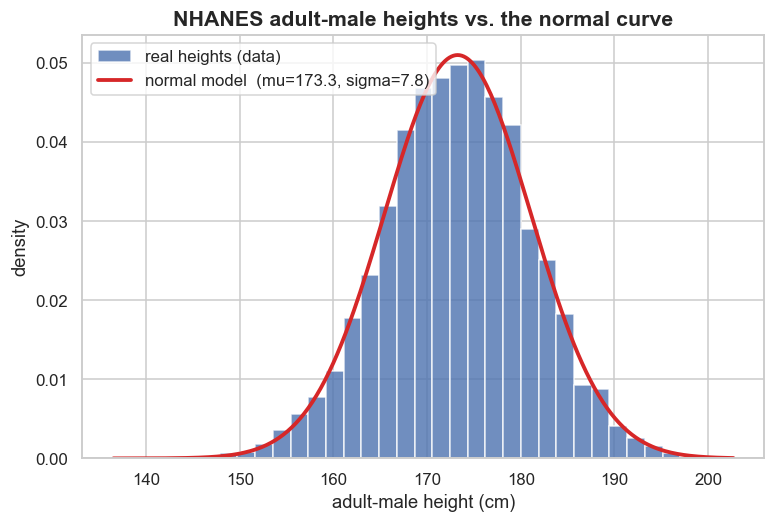

The red curve sits right on top of the blue bars -> these heights are very nearly normal.


In [2]:
# Histogram of REAL heights (density=True so bar areas sum to 1, matching the curve)
fig, ax = plt.subplots()
ax.hist(height_cm, bins=35, density=True, color='#4c72b0',
        edgecolor='white', alpha=0.8, label='real heights (data)')

# The smooth normal curve built from the data's own mu and sd
x = np.linspace(height_cm.min(), height_cm.max(), 300)
ax.plot(x, stats.norm.pdf(x, mu, sd), color='#d62728', lw=2.5,
        label=f'normal model  (mu={mu:.1f}, sigma={sd:.1f})')

ax.set_xlabel('adult-male height (cm)'); ax.set_ylabel('density')
ax.set_title('NHANES adult-male heights vs. the normal curve')
ax.legend(); plt.show()
print('The red curve sits right on top of the blue bars -> these heights are very nearly normal.')

**The interpretation.** The smooth curve traces the bars almost exactly — noticeably tighter than the fit on Galton's ~900 children, because a larger sample fills in the histogram and smooths out the random jaggedness. This does **not** mean heights are *perfectly* normal (no real data ever is), but the normal model is a *very* good description here, so we can borrow its math with confidence. The next two sections then come almost for free.

## 2) The empirical rule: 68 – 95 – 99.7

For *any* normal curve, the same fixed fractions of the data fall within 1, 2, and 3 standard deviations of the mean. This is the famous **empirical rule**:

| Within… | Range | Normal says |
|---|---|---|
| **1 SD** | $\mu \pm \sigma$ | $\approx 68\%$ |
| **2 SD** | $\mu \pm 2\sigma$ | $\approx 95\%$ |
| **3 SD** | $\mu \pm 3\sigma$ | $\approx 99.7\%$ |

**The meaning.** "Almost everybody is within 2 SDs; practically everybody is within 3." It turns a standard deviation from an abstract number into an intuitive ruler.

In the core lesson, Galton's 1-SD band came in about 6 points *under* 68% — a reminder that the rule is only an approximation on a smallish sample. Let's **count** what fraction of these 5,000 men actually land in each band and see whether the bigger, cleaner sample does better.

In [3]:
print(f"{'band':<12}{'data (counted)':>16}{'normal (theory)':>18}")
print('-' * 46)
theory = {1: 68.0, 2: 95.0, 3: 99.7}
for k in (1, 2, 3):
    lo, hi = mu - k * sd, mu + k * sd
    frac = ((height_cm >= lo) & (height_cm <= hi)).mean() * 100
    print(f"mu +/- {k} SD {frac:>14.1f}% {theory[k]:>16.1f}%")

band          data (counted)   normal (theory)
----------------------------------------------
mu +/- 1 SD           68.8%             68.0%
mu +/- 2 SD           95.2%             95.0%
mu +/- 3 SD           99.7%             99.7%


**This is the headline.** All three bands land almost *exactly* on the textbook values: about **68.8%** within 1 SD, **95.2%** within 2 SD, and **99.7%** within 3 SD. Compare that to Galton's rough 1-SD band that fell 6 points short. With five times the data and a careful, standardized measurement, the empirical rule isn't just *close* — it's nearly perfect. Bigger, cleaner samples reveal the underlying bell shape that a smaller sample only hints at. Now let's **see** those bands painted onto the histogram.

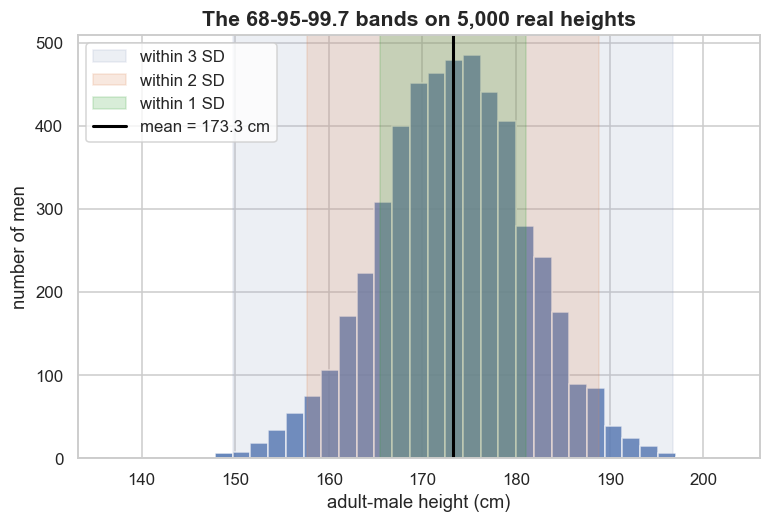

In [4]:
fig, ax = plt.subplots()
ax.hist(height_cm, bins=35, color='#4c72b0', edgecolor='white', alpha=0.85)

# Shade the 1/2/3 SD bands from widest (faintest) to narrowest (boldest)
band_colors = ['#9aa7c7', '#dd8452', '#2ca02c']
for k, c in zip((3, 2, 1), band_colors):
    ax.axvspan(mu - k * sd, mu + k * sd, color=c, alpha=0.18,
               label=f'within {k} SD')
ax.axvline(mu, color='black', lw=2, label=f'mean = {mu:.1f} cm')

ax.set_xlabel('adult-male height (cm)'); ax.set_ylabel('number of men')
ax.set_title('The 68-95-99.7 bands on 5,000 real heights')
ax.legend(); plt.show()

## 3) The punchline: a z-score becomes a *probability*

A z-score tells us *how far from average* a value sits — but the normal model goes further and tells us *what fraction of people are beyond it*. The missing piece is the **cumulative distribution function (CDF)**, the running total of area under the curve.

**The math.** First convert the question to a z-score, then read off the area under the curve.

$$z = \frac{x - \mu}{\sigma}, \qquad P(\text{taller than } x) = \text{sf}(z) = 1 - \text{CDF}(z).$$

Here `stats.norm.cdf(z)` is the area to the **left** of $z$ (the fraction *below*), and `stats.norm.sf(z)` ("survival function") is the area to the **right** (the fraction *above*). Let's ask: **what fraction of these men are taller than 190 cm** (about 6 ft 3 in)? — and compare the normal model's prediction with a direct head-count of the real data.

In [5]:
cutoff = 190.0                                    # cm  (<- tinker: try 180, 173, 200)
z = (cutoff - mu) / sd

normal_pct    = stats.norm.sf(z) * 100            # theory: area under the curve, right of z
empirical_pct = (height_cm > cutoff).mean() * 100 # reality: just count them

print(f"Question: what fraction of men are taller than {cutoff:.0f} cm?")
print(f"  z-score                = {z:.3f}  (i.e. {z:.2f} SDs above the mean)")
print(f"  NORMAL prediction      = {normal_pct:5.2f}%   (from the bell curve, mu & sigma only)")
print(f"  EMPIRICAL (counted)    = {empirical_pct:5.2f}%   (from the real 5,000 men)")
print(f"  difference             = {abs(normal_pct - empirical_pct):5.2f} percentage points")

Question: what fraction of men are taller than 190 cm?
  z-score                = 2.141  (i.e. 2.14 SDs above the mean)
  NORMAL prediction      =  1.61%   (from the bell curve, mu & sigma only)
  EMPIRICAL (counted)    =  1.45%   (from the real 5,000 men)
  difference             =  0.16 percentage points


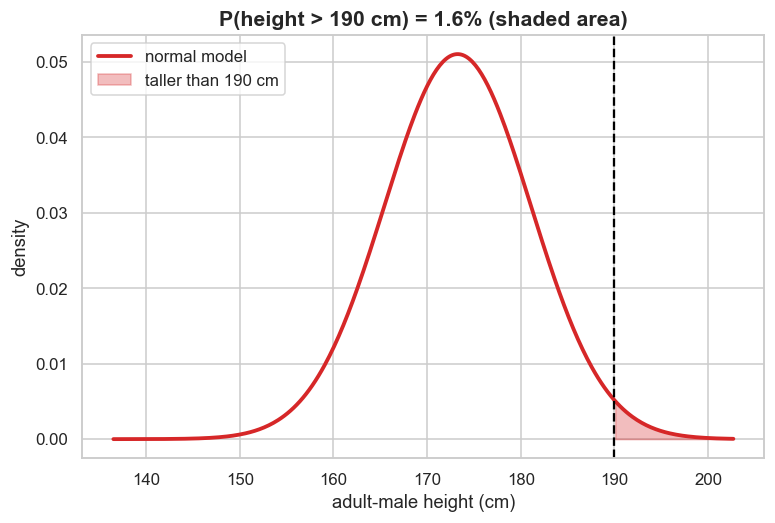

In [6]:
# Picture the question: shade the tail beyond the cutoff under the normal curve.
fig, ax = plt.subplots()
x = np.linspace(height_cm.min(), height_cm.max(), 400)
y = stats.norm.pdf(x, mu, sd)
ax.plot(x, y, color='#d62728', lw=2.5, label='normal model')
tail = x >= cutoff
ax.fill_between(x[tail], y[tail], color='#d62728', alpha=0.30,
                label=f'taller than {cutoff:.0f} cm')
ax.axvline(cutoff, color='black', lw=1.5, ls='--')
ax.set_xlabel('adult-male height (cm)'); ax.set_ylabel('density')
ax.set_title(f'P(height > {cutoff:.0f} cm) = {normal_pct:.1f}% (shaded area)')
ax.legend(); plt.show()

**The interpretation.** The bell curve predicts roughly **1.6%** of men are over 190 cm, and a direct head-count of the data gives roughly **1.5%** — agreement to within a fraction of a percentage point. *This is the new power.* Because the data is so close to normal, you no longer need the 5,000-person dataset in front of you to answer "how rare is this height?" — you need only $\mu$, $\sigma$, and a z-score. (On Galton's smaller sample the model and the count agreed too, but here the match is even tighter, right out into the rare tail.) The same trick runs *backwards*: ask "how tall must a man be to crack the top 10%?" and `stats.norm.ppf` (the **percentile function**) hands you the height.

In [7]:
# Run the trick BACKWARDS: from a percentile to a height.
top_pct = 0.90                                    # the 90th percentile = top 10% cutoff
z_p   = stats.norm.ppf(top_pct)                   # the z that leaves 90% below it
predicted = mu + z_p * sd                          # convert that z back to centimetres
actual    = height_cm.quantile(top_pct)            # the real 90th-percentile height

print(f"To be in the tallest 10%, the normal model says you need > {predicted:.1f} cm.")
print(f"The real data's 90th percentile is               {actual:.1f} cm.  (close!)")

To be in the tallest 10%, the normal model says you need > 183.3 cm.
The real data's 90th percentile is               183.1 cm.  (close!)


## 4) The standard normal $N(0,1)$ — and a peek at confidence intervals

Convert *every* height to its z-score and the whole bell collapses onto one universal curve: the **standard normal**, written $N(0,1)$ — mean $0$, standard deviation $1$. It's the master ruler that every normal distribution shares, no matter its units. Our heights in centimetres and Galton's in inches land on the *same* standard curve once standardized.

One number on it is worth remembering. The central **95%** of a normal distribution sits between $z = -1.96$ and $z = +1.96$:

$$P(-1.96 \le z \le 1.96) = 0.95.$$

In [8]:
z_star = stats.norm.ppf(0.975)   # the z with 97.5% below it -> leaves 2.5% in each tail
mid    = stats.norm.cdf(1.96) - stats.norm.cdf(-1.96)
print(f"95% of a normal curve lies within z = +/- {z_star:.2f}")
print(f"Check: area between -1.96 and +1.96 = {mid*100:.1f}%")

# Translate that band back into actual heights for these men:
lo, hi = mu - 1.96 * sd, mu + 1.96 * sd
print(f"\nSo about 95% of these men are between {lo:.1f} cm and {hi:.1f} cm.")

95% of a normal curve lies within z = +/- 1.96
Check: area between -1.96 and +1.96 = 95.0%

So about 95% of these men are between 157.9 cm and 188.6 cm.


**The interpretation.** That magic **1.96** is the seed of nearly every "95%" you'll ever see quoted. In a few lessons it becomes the engine of a **95% confidence interval** — a range, built as roughly "estimate $\pm 1.96$ standard errors," that pins down an unknown true value. File 1.96 away; it's coming back.

## 5) Is it *really* normal? The Q-Q plot

Eyeballing a histogram is rough. The sharper tool is a **quantile-quantile (Q-Q) plot**: it sorts the data and plots each value against the value the normal model *expected* at that rank.

**How to read it:** if the points fall along a **straight line**, the data is close to normal. **Bends and S-curves reveal skew or fat tails** — places where reality departs from the bell. With 5,000 men the line should be remarkably clean.

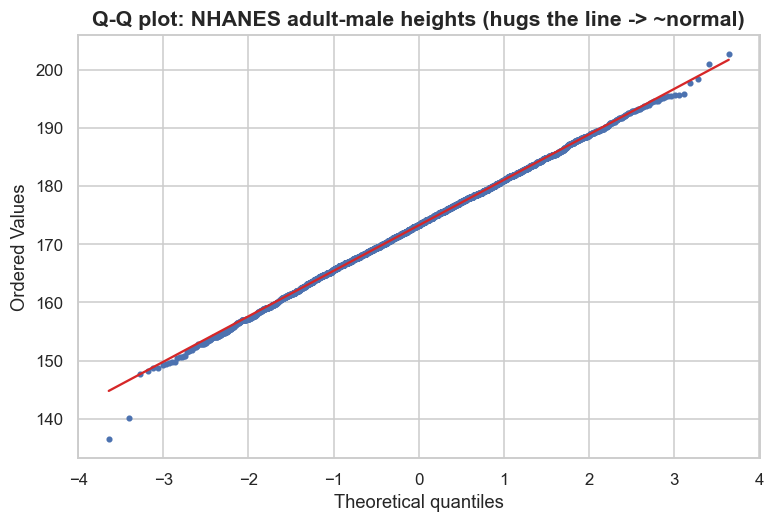

In [9]:
fig, ax = plt.subplots()
stats.probplot(height_cm, plot=ax)             # builds the Q-Q plot for us
ax.get_lines()[0].set_color('#4c72b0')         # the data points
ax.get_lines()[0].set_markersize(3)
ax.get_lines()[1].set_color('#d62728')         # the 'perfectly normal' reference line
ax.set_title('Q-Q plot: NHANES adult-male heights (hugs the line -> ~normal)')
plt.show()

The height points ride along the red line almost the entire way — about as straight a Q-Q plot as real data produces. To see what a **failure** looks like, let's run the same plot on a famously *skewed* variable: borrowers' **annual income** from the Lending Club loans data.

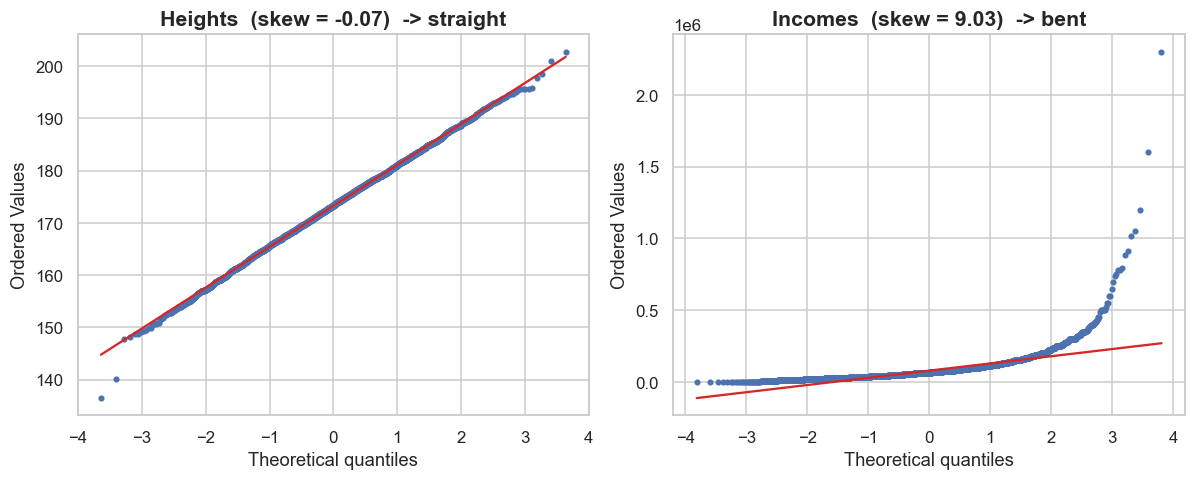

Heights: points on the line (normal).  Income: a sharp upward bend (right-skewed, NOT normal).


In [10]:
loans = sl.load_csv('loans.csv', url='https://www.openintro.org/data/csv/loans_full_schema.csv')
income = loans['annual_income'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
stats.probplot(height_cm, plot=axes[0])
axes[0].set_title(f'Heights  (skew = {height_cm.skew():.2f})  -> straight')
stats.probplot(income, plot=axes[1])
axes[1].set_title(f'Incomes  (skew = {income.skew():.2f})  -> bent')
for axx in axes:
    axx.get_lines()[0].set_color('#4c72b0'); axx.get_lines()[0].set_markersize(3)
    axx.get_lines()[1].set_color('#d62728')
plt.tight_layout(); plt.show()
print('Heights: points on the line (normal).  Income: a sharp upward bend (right-skewed, NOT normal).')

**The interpretation.** Heights are normal; income is emphatically not — it curves up and away because a few very high earners stretch the right tail. That contrast is the whole point: **the empirical rule and the z-to-probability trick only apply when the data is roughly normal.** Always check the shape before you trust the bell-curve math.

## What the bigger sample taught us

Side by side with the core lesson, the moral is clear:

| | Galton (core lesson) | NHANES (this lesson) |
|---|---|---|
| Who | ~934 children, 1880s English families | ~5,092 adult men, US 2015–2018 |
| Units | inches | millimetres → converted to cm |
| 1-SD band | ~62% (about 6 points light) | **~68.8%** (textbook) |
| 2-SD band | ~96% | **~95.2%** (textbook) |
| 3-SD band | ~99.5% | **~99.7%** (textbook) |
| z-to-probability | model ≈ count | model ≈ count, even tighter |

A bigger, more carefully measured modern sample doesn't *change* the bell curve — it reveals it more faithfully. The jagged edges of a small sample smooth out, and the empirical rule and the normal model's predictions snap almost exactly onto the textbook values. That's strong evidence the normal distribution genuinely describes real human heights.

## Now you try

Predict the answer first, then change one thing and re-run:

1. In the section-3 cell, change `cutoff = 190.0` to **180.0**. Before running: will the *fraction taller* go up or down? Do the normal prediction and the count still agree closely?
2. In the same cell, set `cutoff = mu` (exactly the mean). What percentage do you expect to be taller? Run it and confirm the bell curve says ~50% — and that the real-data count agrees, because the distribution is so symmetric.
3. In the backwards cell, change `top_pct = 0.90` to **0.99** (the top 1%). How tall must a man be? Does the normal model still match the data's real 99th percentile, or does the rare tail start to disagree?
4. In the setup cell, recompute `sd` with `height_cm.std(ddof=0)` instead of `ddof=1`. With 5,000 rows, does the standard deviation — and therefore the empirical-rule bands — change in any way you can see? (This is the "n vs. n−1" question; on a big sample the difference all but vanishes.)

## What you learned

- **The units matter:** NHANES height arrives in **millimetres** (`BMXHT`); dividing by 10 gives centimetres. Always check units before trusting an average.
- **The math:** a normal curve is fully described by two numbers, $\mu \approx 173$ cm and $\sigma \approx 7.8$ cm, through $f(x)=\frac{1}{\sigma\sqrt{2\pi}}e^{-\frac12((x-\mu)/\sigma)^2}$.
- **The meaning:** on ~5,000 men the **empirical rule** lands almost exactly on $68\%/95\%/99.7\%$ — far cleaner than Galton's smaller sample, because more data reveals the true bell shape.
- **The power:** a **z-score** plus the normal **CDF** turns "how unusual?" into a **probability** — the model predicts ~1.6% of men over 190 cm, and a head-count gives ~1.5%.
- **The standard normal** $N(0,1)$ is the universal ruler that heights in cm and inches both share; $\pm 1.96$ encloses the central 95% and seeds the confidence interval.
- **The caution:** a **Q-Q plot** confirms heights ride the line while skewed income bends away — the bell-curve tricks only work when the shape is actually normal.

**Back to the core lesson** for the Galton story and where this leads next: the **Central Limit Theorem**, which reveals *why* the normal curve turns up everywhere.

---

**↩ Back to the lesson:** [Lesson 9: The normal distribution & the empirical rule](09-normal-distribution.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Also:** [The code behind it](09-normal-distribution~the-code.ipynb)